# 03 · Measurements for every probe
*One cosmology-free output — the `MeasurementSet` — for clustering, lensing, velocities, supernovae, Lyα and maps.*

`oneuniverse.measure` runs a nine-step preparation pipeline and emits one container regardless of probe. Cosmology never enters — it is chosen later, at the estimator call, so the same prepared measurement is reusable under any fiducial. Real eBOSS for clustering; controlled synthetic data for the probes whose real catalogs are not on disk.

In [1]:
%matplotlib inline
import os, sys, json, time, sqlite3, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow, Rectangle, FancyBboxPatch
plt.rcParams.update({'figure.dpi':115,'font.size':10.5,'axes.titlesize':11.5,
    'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'white'})
C0,C1,C2,C3,C4 = '#3a6ea5','#d1495b','#3c8d53','#edae49','#7d5ba6'
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_REAL = EBOSS.exists() and DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
def moll(ax, ra, dec, **kw):
    lon = np.radians(((np.asarray(ra)+180)%360)-180)
    ax.scatter(lon, np.radians(dec), **kw)
print('real eBOSS+DESI available:', HAVE_REAL)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS+DESI available: True


## The nine-step pipeline

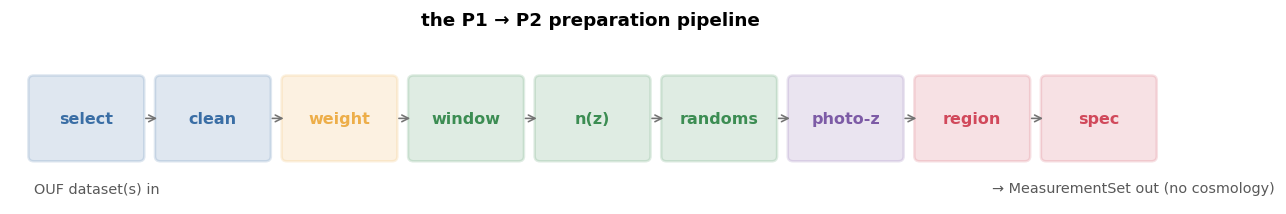

In [2]:
steps=['select','clean','weight','window','n(z)','randoms','photo-z','region','spec']
cols=[C0,C0,C3,C2,C2,C2,C4,C1,C1]
fig,ax=plt.subplots(figsize=(13,1.9)); ax.axis('off'); ax.set_xlim(0,13); ax.set_ylim(0,2)
for i,(s,c) in enumerate(zip(steps,cols)):
    x=0.25+i*1.42
    ax.add_patch(FancyBboxPatch((x,0.55),1.18,0.9,boxstyle='round,pad=0.06',fc=c,alpha=.16,ec=c,lw=1.6))
    ax.text(x+0.59,1.0,s,ha='center',va='center',fontsize=10,fontweight='bold',color=c)
    if i<8: ax.annotate('',(x+1.42,1.0),(x+1.22,1.0),arrowprops=dict(arrowstyle='->',color='.45'))
ax.text(0.25,0.12,'OUF dataset(s) in',fontsize=9,color='.35')
ax.text(11.0,0.12,'→ MeasurementSet out (no cosmology)',fontsize=9,color='.35')
ax.set_title('the P1 → P2 preparation pipeline'); plt.show()

## Galaxy clustering on real eBOSS
Catalog + FKP weights + generated randoms + n(z) + footprint + shared jackknife regions — and the statistical checks that the selection model is faithful.

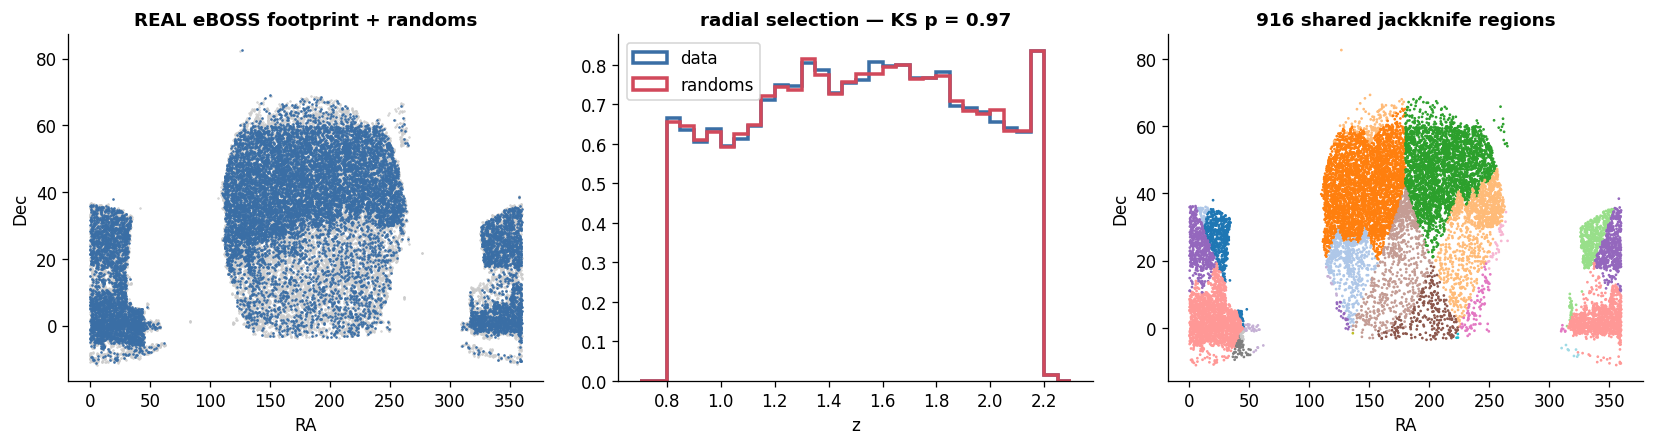

invariants OK | covered sky fraction 0.210


In [3]:
def load_qso(name, zlo=0.8, zhi=2.2, cap=60000, seed=0):
    '''Real survey catalog via the registered P1 loader (synthetic fallback).'''
    if not HAVE_REAL:
        from fixtures.measure_ouf import synthetic_point_view
        return synthetic_point_view(TMP, n=cap, seed=seed, name=name).read(), False
    os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
    from oneuniverse.data import load_catalog
    df = load_catalog(name, validate=False)
    df = df[(df['z']>=zlo)&(df['z']<=zhi)].dropna(subset=['ra','dec','z'])
    if len(df)>cap: df=df.sample(cap, random_state=seed)
    return df.reset_index(drop=True), True
def to_ouf_view(df, tmp, name, extra_cols=()):
    '''Write a DataFrame as an OUF 2.6 POINT dataset; return its DatasetView.'''
    from oneuniverse.data.converter import write_ouf_dataset
    from oneuniverse.data.dataset_view import DatasetView
    from oneuniverse.data.format_spec import DataGeometry
    from oneuniverse.data.manifest import LoaderSpec
    n=len(df); ra=df['ra'].to_numpy(float); dec=df['dec'].to_numpy(float)
    out={'ra':ra,'dec':dec,'z':df['z'].to_numpy(float),'z_type':np.full(n,'spec'),
         'z_err':np.full(n,1e-4),'galaxy_id':np.arange(n,dtype=np.int64),
         'survey_id':np.zeros(n,dtype=np.int64),'weight_comp':np.ones(n),
         '_original_row_index':np.arange(n,dtype='i8'),
         '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')}
    for c in extra_cols:
        out[c]=df[c].to_numpy()
    od=tmp/name/'oneuniverse'
    write_ouf_dataset(df=pd.DataFrame(out),out_dir=od,survey_name=name,
        survey_type='spectroscopic',geometry=DataGeometry.POINT,
        loader=LoaderSpec(name=name,version='0'))
    return DatasetView.from_path(od.parent)
from oneuniverse.combine.weights import FKPWeight
from oneuniverse import measure
from scipy import stats
eb,real = load_qso('eboss_qso', cap=50000, seed=1)
view = to_ouf_view(eb, TMP, 'eboss')
ms = measure.build_galaxy_clustering(view, tracer='qso', z_range=(0.8,2.2),
    weights=[FKPWeight(nbar=lambda z: np.full_like(z,1e-3), P0=1e4)],
    nside_window=64, nside_region=16, nz_edges=np.linspace(0.7,2.3,33),
    randoms='generate', n_randoms=3*len(eb), seed=1)
ps=ms.products['qso']; cat,rnd,nz=ps.catalog,ps.randoms,ps.nz
ks=stats.ks_2samp(cat['z'],rnd['z'])
fig,ax=plt.subplots(1,3,figsize=(14.5,4))
ax[0].scatter(rnd['ra'][::6],rnd['dec'][::6],s=.25,c='.8')
ax[0].scatter(cat['ra'][::3],cat['dec'][::3],s=.4,c=C0)
ax[0].set_title(('REAL eBOSS' if real else 'synthetic')+' footprint + randoms')
ax[0].set_xlabel('RA'); ax[0].set_ylabel('Dec')
ax[1].hist(cat['z'],bins=nz.edges,density=True,histtype='step',lw=2.2,color=C0,label='data')
ax[1].hist(rnd['z'],bins=nz.edges,density=True,histtype='step',lw=2.2,color=C1,label='randoms')
ax[1].set_title(f'radial selection — KS p = {ks.pvalue:.2f}'); ax[1].set_xlabel('z'); ax[1].legend()
sc=ax[2].scatter(cat['ra'][::3],cat['dec'][::3],s=.5,c=cat['region_id'][::3],cmap='tab20')
ax[2].set_title(f"{cat['region_id'].nunique()} shared jackknife regions")
ax[2].set_xlabel('RA'); ax[2].set_ylabel('Dec')
plt.tight_layout(); plt.show()
ms.check_invariants(); print('invariants OK | covered sky fraction %.3f' % ps.window.covered_fraction())

## Weak lensing: shapes + the photo-z kernel
The source PointSet carries ellipticities with metacal calibration and the full **per-object p(z) kernel** — shown as a waterfall, sorted by mean redshift — which stacks into the tomographic n(z).

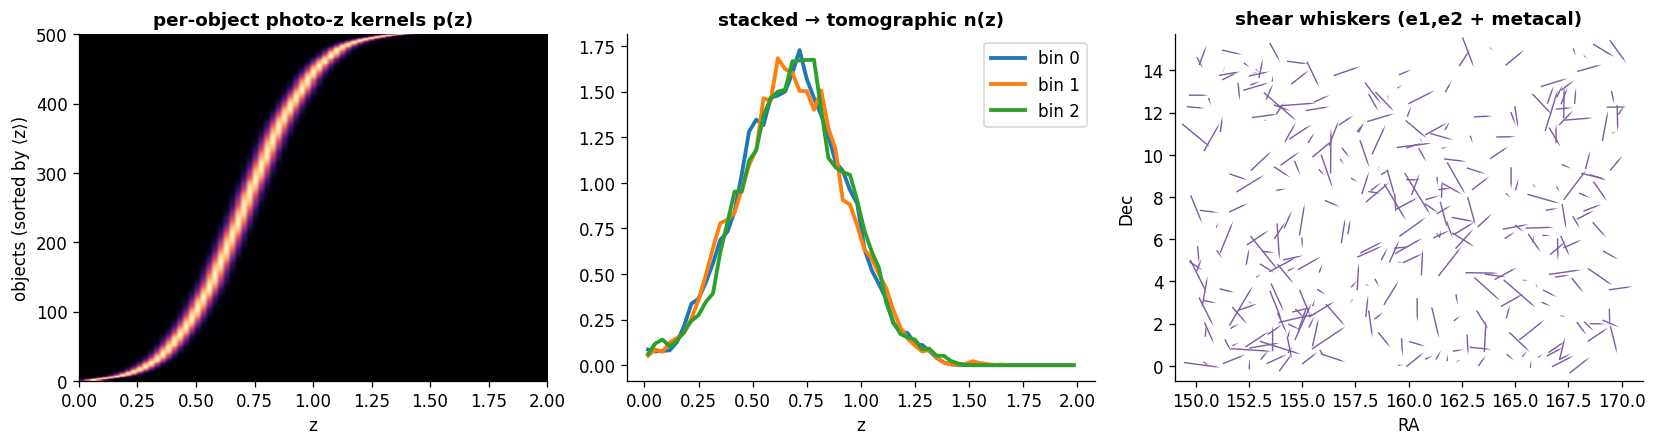

shape columns carried: ['e1', 'e2', 'e1_err', 'e2_err', 'R11', 'R22', 'R_S', 'm_bias', 'c1_bias', 'c2_bias', 'shear_weight']


In [4]:
from fixtures.measure_ouf import synthetic_shear_view
sv = synthetic_shear_view(TMP, n=6000, seed=3, kind='metacal', with_pdf=True, n_tomo=3, name='src')
wl = measure.build_cosmic_shear(sv, tomo_column='tomo_bin', z_grid=np.linspace(0,2,61), nside_region=8)
src=wl.products['src']; pz=src.photoz
order=np.argsort(pz.mean()); V=np.asarray(pz.values)[order][::12]
fig,ax=plt.subplots(1,3,figsize=(14.5,4))
ax[0].imshow(V,aspect='auto',origin='lower',extent=[pz.grid[0],pz.grid[-1],0,len(V)],cmap='magma')
ax[0].set_xlabel('z'); ax[0].set_ylabel('objects (sorted by ⟨z⟩)')
ax[0].set_title('per-object photo-z kernels p(z)')
for b,n in sorted(src.nz.items()): ax[1].plot(n.centers(),n.pdf(),lw=2.4,label=f'bin {b}')
ax[1].set_title('stacked → tomographic n(z)'); ax[1].set_xlabel('z'); ax[1].legend()
s=src.catalog.iloc[::18]; emag=np.hypot(s['e1'],s['e2']); ang=.5*np.arctan2(s['e2'],s['e1'])
ax[2].quiver(s['ra'],s['dec'],emag*np.cos(ang),emag*np.sin(ang),headwidth=0,headlength=0,pivot='mid',scale=8,width=.003,color=C4)
ax[2].set_title('shear whiskers (e1,e2 + metacal)'); ax[2].set_xlabel('RA'); ax[2].set_ylabel('Dec')
plt.tight_layout(); plt.show()
print('shape columns carried:', src.attributes['shapes'])

## The probe gallery — one container, six builders

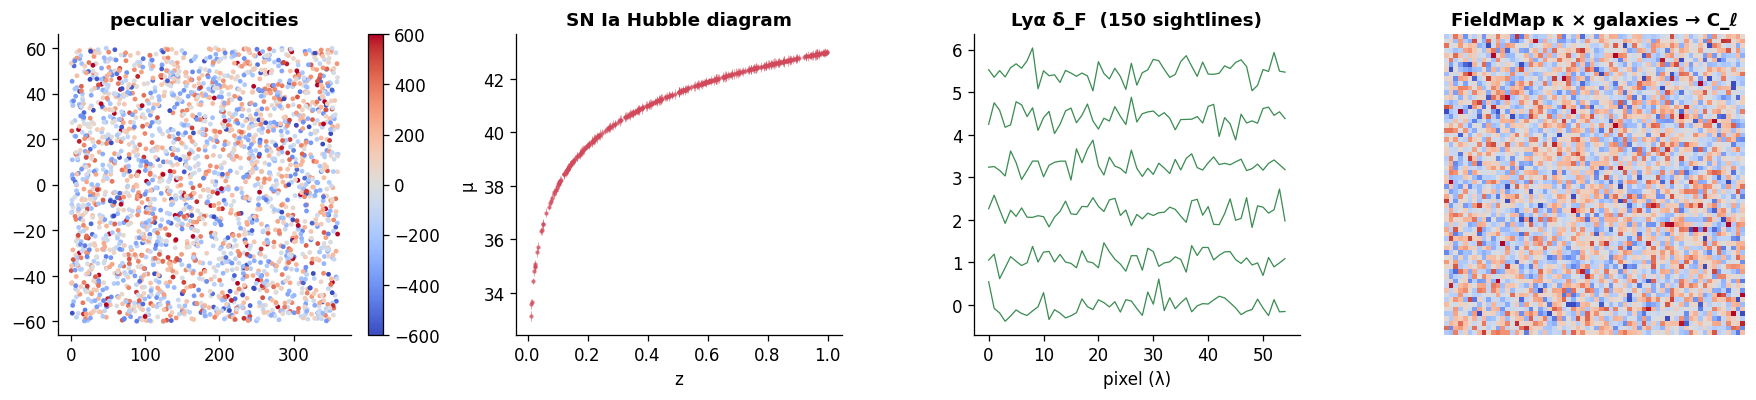

clustering     family=clustering statistic=pk_multipole     pointset
cosmic shear   family=lensing    statistic=xi_pm            pointset
pec. velocity  family=velocity   statistic=velocity_correlation pointset
SN Ia          family=sn         statistic=hubble           pointset
Lyα            family=lya        statistic=p1d              sightline
gal×κ          family=cross      statistic=cl               fieldmap+pointset


In [5]:
from fixtures.measure_ouf import (synthetic_pv_view, synthetic_sn_view,
    synthetic_sightline_view, synthetic_healpix_map, synthetic_point_view)
from oneuniverse.measure.fieldmap import fieldmap_from_healpix
pv=measure.build_peculiar_velocity(synthetic_pv_view(TMP,n=2500,seed=3,name='pv'),z_range=(0,0.1),nside_region=8)
snv,_=synthetic_sn_view(TMP,n=350,seed=4,name='sn'); sn=measure.build_sn_hubble(snv,nside_region=4)
lya=measure.build_lya(synthetic_sightline_view(TMP,n_los=150,n_pix=55,seed=2,name='lya'),nside_region=8)
vals,mask=synthetic_healpix_map(nside=64,seed=4)
fm=fieldmap_from_healpix(vals,mask=mask,nside=64,dataset_id='cmbk')
xc=measure.build_map_cross(synthetic_point_view(TMP,n=4000,seed=3,name='g2'),fm,nside_region=8,z_range=(0.1,1.0))
fig,ax=plt.subplots(1,4,figsize=(15.5,3.6))
p0=pv.products['pv'].catalog
s0=ax[0].scatter(p0['ra'],p0['dec'],s=4,c=p0['v_pec'],cmap='coolwarm',vmin=-600,vmax=600)
ax[0].set_title('peculiar velocities'); plt.colorbar(s0,ax=ax[0],fraction=.05)
s1=sn.products['sn'].catalog
ax[1].errorbar(s1['z'],s1['mu'],yerr=s1['mu_err'],fmt='.',ms=3.5,alpha=.6,elinewidth=.5,color=C1)
ax[1].set_title('SN Ia Hubble diagram'); ax[1].set_xlabel('z'); ax[1].set_ylabel('μ')
sl=lya.products['lya']
for i in range(6): ax[2].plot(sl.delta[i]+i*1.1,lw=.8,color=C2)
ax[2].set_title(f'Lyα δ_F  ({sl.n_sightlines} sightlines)'); ax[2].set_xlabel('pixel (λ)')
patch=fm.values[:4096].reshape(64,64)
ax[3].imshow(patch,cmap='coolwarm',vmin=-2.5,vmax=2.5); ax[3].axis('off')
ax[3].set_title('FieldMap κ × galaxies → C_ℓ')
plt.tight_layout(); plt.show()
for nm,m in [('clustering',ms),('cosmic shear',wl),('pec. velocity',pv),('SN Ia',sn),('Lyα',lya),('gal×κ',xc)]:
    s=m.summary(); kinds='+'.join(sorted({p['kind'] for p in s['products'].values()}))
    print(f"{nm:14s} family={s['spec']['estimator_family']:<10s} statistic={s['spec']['statistic']:<16s} {kinds}")

## Beyond the builders: the generality slots
The container also expresses probes with no one-call builder yet — via **sub-object links** (here: strong-lens systems with time-delay payloads), **named weight components** kept separable, and a **covariance plan**.

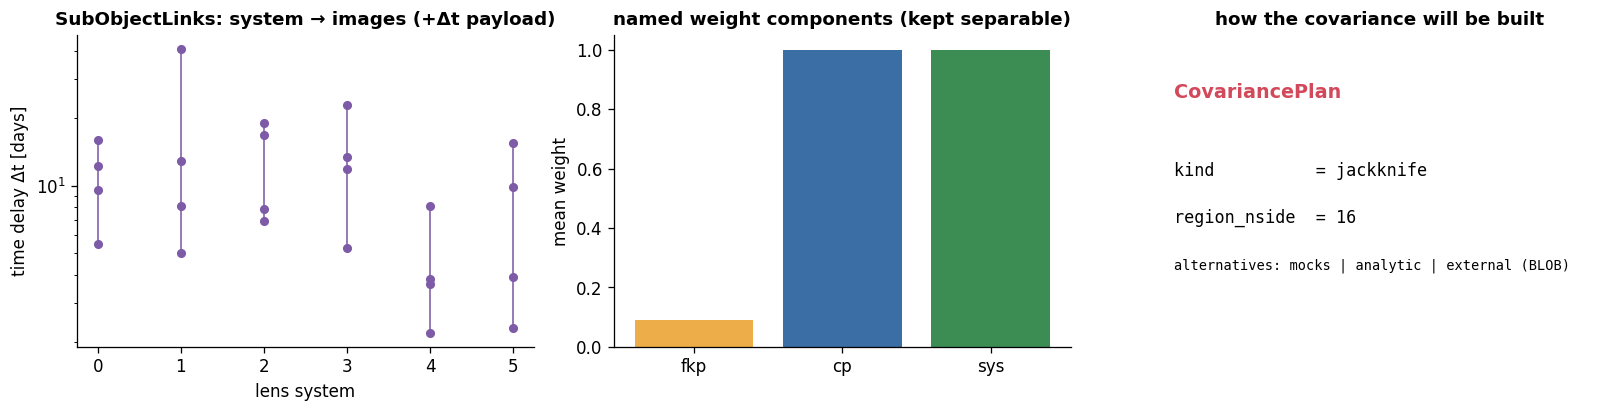

In [6]:
from oneuniverse.measure import SubObjectLinks, CovariancePlan, assemble_named_weights
from oneuniverse.combine.weights import ColumnWeight, FKPWeight
rng=np.random.default_rng(7); n_sys=6
links=SubObjectLinks(role='lens_image', parent_ids=np.repeat(np.arange(n_sys),4),
    child_ids=np.arange(n_sys*4),
    payload={'dt_days': rng.lognormal(2.5,0.9,n_sys*4)})
cat2 = view.read().head(4000).copy(); cat2['w_cp']=1.0; cat2['w_sys']=rng.uniform(.9,1.1,len(cat2))
cat2,nw = assemble_named_weights(cat2, {'fkp':FKPWeight(nbar=lambda z: np.full_like(z,1e-3),P0=1e4),
                                        'cp':ColumnWeight('w_cp'),'sys':ColumnWeight('w_sys')})
fig,ax=plt.subplots(1,3,figsize=(14.5,3.7))
for s_ in range(n_sys):
    dts=links.payload['dt_days'][links.parent_ids==s_]
    ax[0].scatter(np.full(4,s_),dts,s=22,c=C4); ax[0].plot([s_,s_],[dts.min(),dts.max()],c=C4,lw=1)
ax[0].set_xlabel('lens system'); ax[0].set_ylabel('time delay Δt [days]'); ax[0].set_yscale('log')
ax[0].set_title('SubObjectLinks: system → images (+Δt payload)')
comps=list(nw.components); means=[nw.components[c].mean() for c in comps]
ax[1].bar(comps,means,color=[C3,C0,C2]); ax[1].set_title('named weight components (kept separable)')
ax[1].set_ylabel('mean weight')
ax[2].axis('off')
plan=CovariancePlan(kind='jackknife',region_nside=16)
ax[2].text(.05,.8,'CovariancePlan',fontsize=12,fontweight='bold',color=C1)
ax[2].text(.05,.55,f'kind          = {plan.kind}',family='monospace')
ax[2].text(.05,.4,f'region_nside  = {plan.region_nside}',family='monospace')
ax[2].text(.05,.25,"alternatives: mocks | analytic | external (BLOB)",family='monospace',fontsize=8.5)
ax[2].set_title('how the covariance will be built')
plt.tight_layout(); plt.show()

## The handoff: save → reload → SQL
A `MeasurementSet` persists to a self-describing directory and round-trips losslessly; it also exports to SQLite.

In [7]:
ms.to_dir(TMP/'ms_eboss')
from oneuniverse.measure import MeasurementSet
back = MeasurementSet.from_dir(TMP/'ms_eboss'); back.check_invariants()
same_cat = len(back.products['qso'].catalog)==len(cat)
same_nz = np.allclose(back.products['qso'].nz.counts, nz.counts)
db = ms.to_sql(TMP/'ms.sqlite')
tabs=[r[0] for r in sqlite3.connect(db).execute("SELECT name FROM sqlite_master WHERE type='table'")]
print('round-trip: catalog rows equal:',same_cat,'| n(z) equal:',same_nz)
print('SQL tables:',tabs)
print('summary is JSON-safe:', bool(json.dumps(back.summary())))

round-trip: catalog rows equal: True | n(z) equal: True
SQL tables: ['measurement_sets', 'catalog_qso', 'randoms_qso']
summary is JSON-safe: True


**What this showed.** One pipeline, one container: real-survey clustering with verifiable selection modelling, lensing with the full photo-z kernel, a four-probe gallery, the generality slots that cover builder-less probes, and a handoff that survives disk, relocation and SQL — all without a single cosmological assumption.